# Cohort Selection:  Visualization

Loads the artifacts produced by `cohort_selection.py` and reproduces every plot from the §10 cohort selection strategy section of `dataset_analysis.ipynb`.

Run `cohort_selection.py` first to generate the files this notebook reads.

In [46]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json

DATA_DIR = Path("/home/myriamcharfeddine/CGM/Data/enriched_multimodal")

# Load csv files into pandas DataFrames
cohort_df   = pd.read_csv(DATA_DIR / "cohort.csv") # contains one row per participant, with stratum labels and other metadata
segments_df = pd.read_csv(DATA_DIR / "segments.csv") # contains one row per segment, with segment-level features and labels (e.g. stratum, glycemic pattern)
windows_df  = pd.read_csv(DATA_DIR / "forecast_windows.csv") # contains one row per forecast window, with window-level features and labels (e.g. stratum, glycemic pattern, target label)
seg_stats   = pd.read_csv(DATA_DIR / "segment_stats.csv")# contains one row per segment, with summary statistics (e.g. mean, std) of CGM and insulin features
stratum_rep = pd.read_csv(DATA_DIR / "stage3_stratum_representation.csv") # contains one row per stratum, with representation statistics (e.g. number of participants, segments, windows)

# Optional files (may not exist if --no-sweep or Stage 3.2 was skipped)
sweep_path     = DATA_DIR / "sweep_results.csv" 
dur_sens_path  = DATA_DIR / "sensitivity_duration.csv"
dist_test_path = DATA_DIR / "stage3_distribution_tests.csv"
meta_path      = DATA_DIR / "cohort_selection_metadata.json"

sweep_df     = pd.read_csv(sweep_path)     if sweep_path.exists()     else pd.DataFrame()
sens_dur_df  = pd.read_csv(dur_sens_path)  if dur_sens_path.exists()  else pd.DataFrame()
dist_test_df = pd.read_csv(dist_test_path) if dist_test_path.exists() else pd.DataFrame()
meta_json    = json.load(open(meta_path))  if meta_path.exists()      else {}

# Constants (must match cohort_selection.py)
MIN_DURATION_H  = meta_json.get("config", {}).get("min_duration_h", 108)
CONTEXT_H       = meta_json.get("config", {}).get("context_h", 48)
TARGET_H        = meta_json.get("config", {}).get("target_h", 1)
STRATUM_TOL_PP  = 5.0
GLYCEMIC_STRATA = ["normoglycemia", "prediabetes", "T2D-oral", "T2D-insulin"]
ALL_STRATA      = GLYCEMIC_STRATA + ["unclassified"]
STRATUM_COLORS  = ["#BA2828", "#003366", "#5BBABA", "#FF0000", "#888888"]

print("Files loaded from:", DATA_DIR)
print(f"  Cohort           : {len(cohort_df)} participants")
print(f"  Segments         : {len(segments_df)}")
print(f"  Forecast windows : {len(windows_df):,}")


Files loaded from: /home/myriamcharfeddine/CGM/Data/enriched_multimodal
  Cohort           : 1591 participants
  Segments         : 2619
  Forecast windows : 142,823


## Step 1:  Pre-filter summary

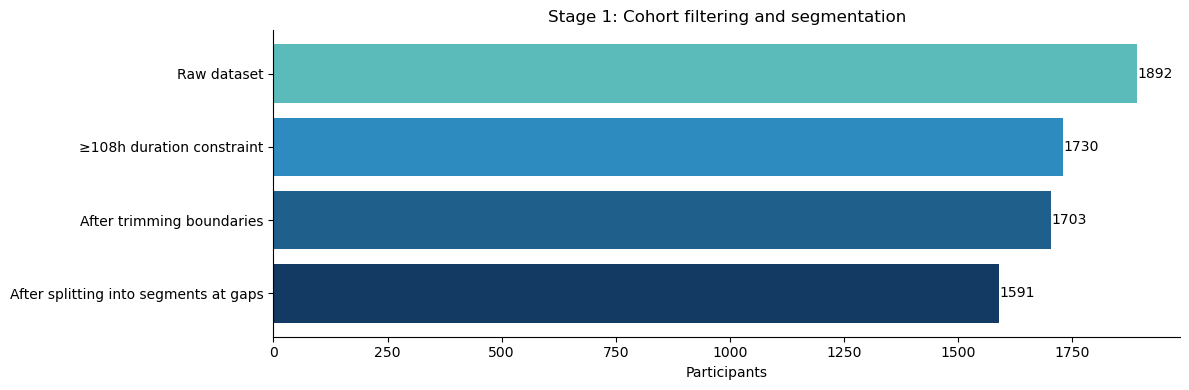

In [47]:
# 1/ stage1

counts = meta_json.get("counts", {})
if counts:
    labels = ["Raw dataset",f"≥{MIN_DURATION_H:.0f}h duration constraint","After trimming boundaries","After splitting into segments at gaps",]
    values = [counts.get("raw", 0),counts.get("after_duration_floor", 0),counts.get("after_trim", 0),counts.get("after_segmentation", 0),]
    fig, ax = plt.subplots(figsize=(12, 4))
    bars = ax.barh(labels[::-1], values[::-1], color=["#123A63", "#1F5F8B", "#2E8BC0", "#5BBABA"])
    for bar, val in zip(bars, values[::-1]):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f"{val}", va="center", fontsize=10)
    ax.set_xlabel("Participants")
    ax.set_title("Stage 1: Cohort filtering and segmentation")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print("Counts not found in metadata JSON, re-run cohort_selection.py")

## Segment distribution

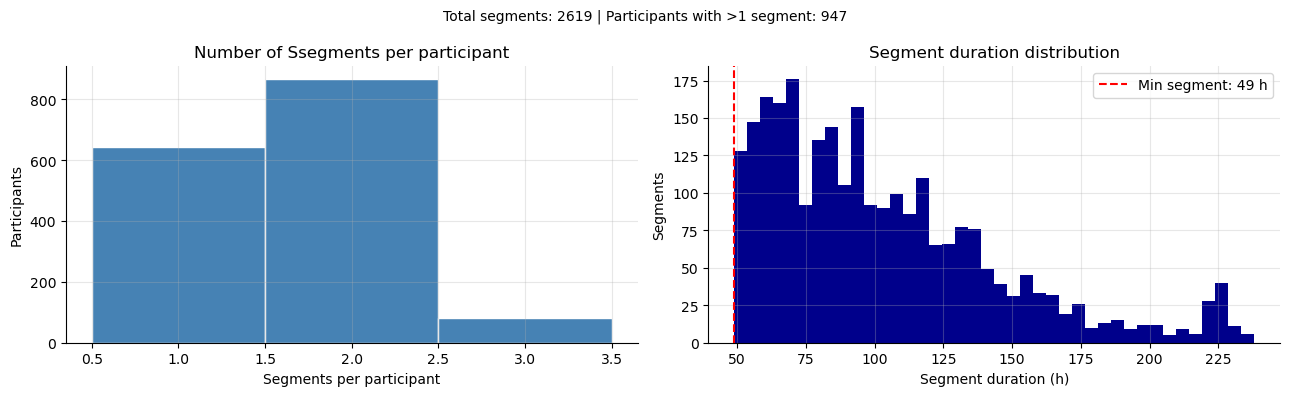

Segments per participant:  mean: 1.65  max: 3
Segment duration (h): mean: 103.0  min: 49.0  max: 238.0


In [48]:
segs_per_pid = segments_df.groupby("participant_id")["segment_id"].count()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(segs_per_pid, bins=range(1, segs_per_pid.max() + 2),
             color="steelblue", edgecolor="white", align="left")
axes[0].set_xlabel("Segments per participant")
axes[0].set_ylabel("Participants")
axes[0].set_title("Number of Ssegments per participant")
axes[0].grid(alpha=0.3)
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].hist(segments_df["dur_h"], bins=40, color="darkblue", edgecolor="none")
axes[1].axvline(CONTEXT_H + TARGET_H, color="red", lw=1.5, linestyle="--",label=f"Min segment: {CONTEXT_H + TARGET_H} h")
axes[1].set_xlabel("Segment duration (h)")
axes[1].set_ylabel("Segments")
axes[1].set_title("Segment duration distribution")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle(f"Total segments: {len(segments_df)} | "f"Participants with >1 segment: {(segs_per_pid > 1).sum()}", fontsize=10)
plt.tight_layout()
plt.show()

print(f"Segments per participant:  mean: {segs_per_pid.mean():.2f}  "
      f"max: {segs_per_pid.max()}")
print(f"Segment duration (h): mean: {segments_df['dur_h'].mean():.1f}  "
      f"min: {segments_df['dur_h'].min():.1f}  "
      f"max: {segments_df['dur_h'].max():.1f}")

## Step 2: Window counts and completeness

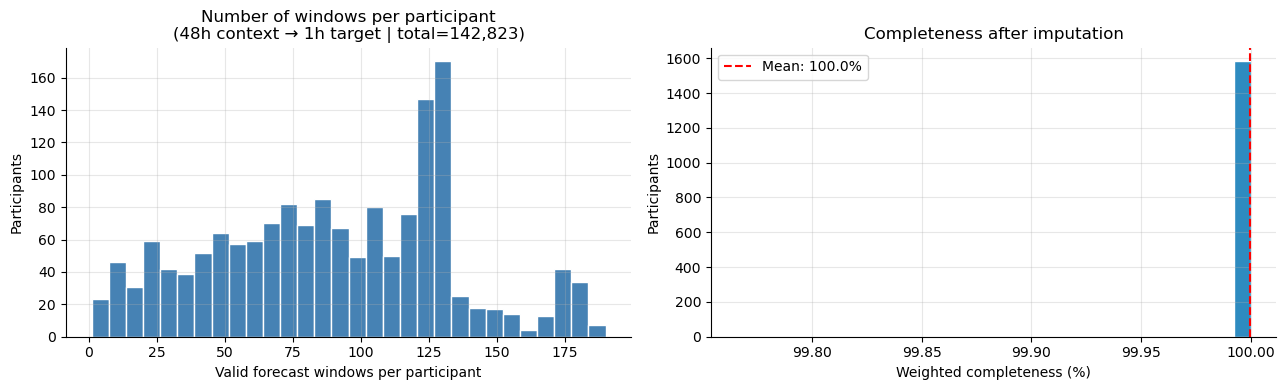

Windows: mean: 89.8  median: 91  total: 142,823

Windows by glycemic state:
  normoglycemia         :  564 participants |  51,315 windows (mean 91/participant)
  prediabetes           :  405 participants |  37,376 windows (mean 92/participant)
  T2D-oral              :  458 participants |  41,240 windows (mean 90/participant)
  T2D-insulin           :  164 participants |  12,892 windows (mean 79/participant)


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(cohort_df["n_valid_windows"].dropna(), bins=30, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Valid forecast windows per participant")
axes[0].set_ylabel("Participants")
axes[0].set_title(f"Number of windows per participant\n"
                  f"(48h context → 1h target | total={cohort_df['n_valid_windows'].sum():,})")
axes[0].grid(alpha=0.3)
axes[0].spines[["top", "right"]].set_visible(False)

wc_col = "weighted_completeness" if "weighted_completeness" in cohort_df.columns else None
if wc_col:
    axes[1].hist(cohort_df[wc_col].dropna() * 100, bins=30, color="#2E8BC0", edgecolor="white")
    axes[1].axvline(cohort_df[wc_col].mean() * 100, color="red", linestyle="--", label=f"Mean: {cohort_df[wc_col].mean()*100:.1f}%")
    axes[1].set_xlabel("Weighted completeness (%)")
    axes[1].set_ylabel("Participants")
    axes[1].set_title("Completeness after imputation")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Windows: mean: {cohort_df['n_valid_windows'].mean():.1f}  "
      f"median: {cohort_df['n_valid_windows'].median():.0f}  "
      f"total: {cohort_df['n_valid_windows'].sum():,}")

if "stratum" in cohort_df.columns:
    print("\nWindows by glycemic state:")
    for s in GLYCEMIC_STRATA:
        sub = cohort_df[cohort_df["stratum"] == s]
        if len(sub):
            print(f"  {s:<22}: {len(sub):4d} participants | "
                  f"{sub['n_valid_windows'].sum():>7,} windows "
                  f"(mean {sub['n_valid_windows'].mean():.0f}/participant)")

## Step 2.1: Sensitivity to duration floor

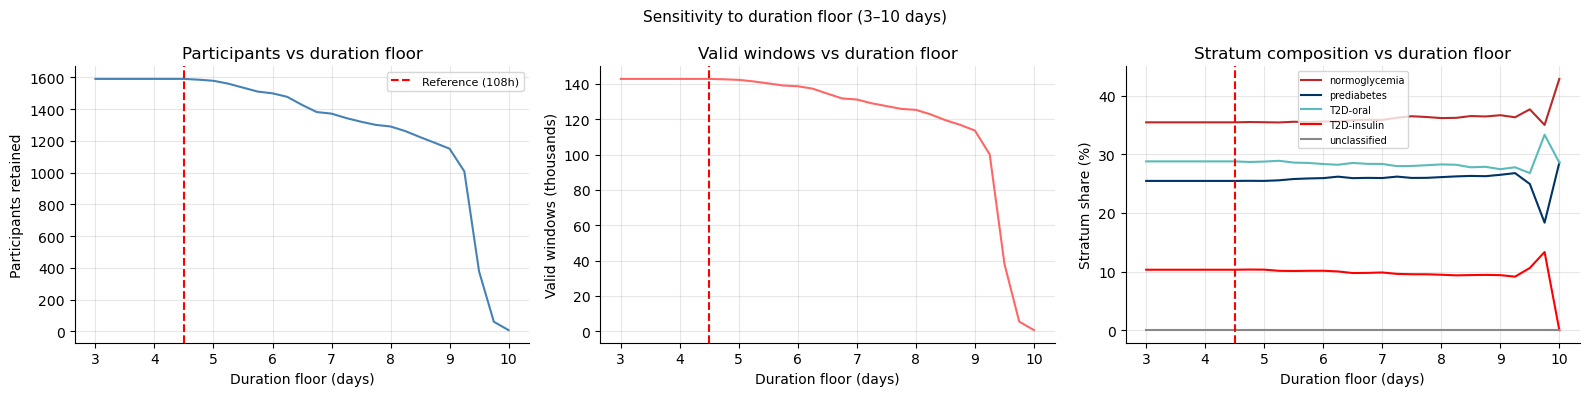

In [50]:
if sens_dur_df.empty:
    print("sensitivity_duration.csv not found — re-run without --no-sweep")
else:
    REF_DUR_D = MIN_DURATION_H / 24

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    ax = axes[0]
    ax.plot(sens_dur_df["dur_floor_d"], sens_dur_df["n_participants"], color="steelblue")
    ax.axvline(REF_DUR_D, color="red", linestyle="--", label=f"Reference ({MIN_DURATION_H:.0f}h)")
    ax.set_xlabel("Duration floor (days)")
    ax.set_ylabel("Participants retained")
    ax.set_title("Participants vs duration floor")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

    ax = axes[1]
    ax.plot(sens_dur_df["dur_floor_d"], sens_dur_df["n_valid_windows"] / 1000, color="#FF6666")
    ax.axvline(REF_DUR_D, color="red", linestyle="--")
    ax.set_xlabel("Duration floor (days)")
    ax.set_ylabel("Valid windows (thousands)")
    ax.set_title("Valid windows vs duration floor")
    ax.grid(alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

    ax = axes[2]
    for s, c in zip(ALL_STRATA, STRATUM_COLORS):
        col = f"pct_{s}"
        if col in sens_dur_df.columns:
            ax.plot(sens_dur_df["dur_floor_d"], sens_dur_df[col], label=s, color=c)
    ax.axvline(REF_DUR_D, color="red", linestyle="--")
    ax.set_xlabel("Duration floor (days)")
    ax.set_ylabel("Stratum share (%)")
    ax.set_title("Stratum composition vs duration floor")
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

    plt.suptitle("Sensitivity to duration floor (3–10 days)", fontsize=11)
    plt.tight_layout()
    plt.show()

## Stage 2.2 Joint sensitivity heatmap (duration × min-windows)

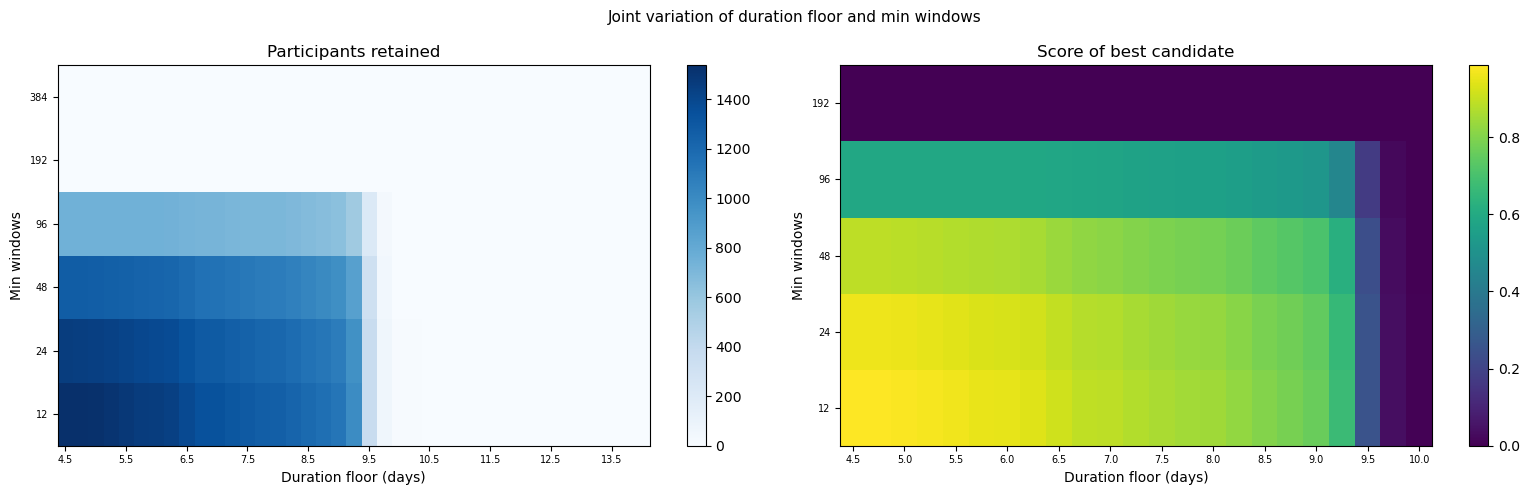

Max-score candidate:  dur=4.50d | min_windows=12 | N=1536 | windows=142,439 | score=0.9860


In [51]:
if sweep_df.empty:
    print("sweep_results.csv not found, re-run without --no-sweep")
else:
    pivot_n = sweep_df.pivot(index="min_windows_thr", columns="dur_thr", values="n_participants")
    pivot_s = sweep_df.pivot(index="min_windows_thr", columns="dur_thr", values="score")

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    im0 = axes[0].imshow(pivot_n.values, aspect="auto", origin="lower", cmap="Blues")
    axes[0].set_xticks(range(0, len(pivot_n.columns), max(1, len(pivot_n.columns)//8)))
    axes[0].set_xticklabels([f"{v:.1f}" for v in
                              pivot_n.columns[::max(1, len(pivot_n.columns)//8)]], fontsize=7)
    axes[0].set_yticks(range(len(pivot_n.index)))
    axes[0].set_yticklabels(pivot_n.index.tolist(), fontsize=7)
    axes[0].set_xlabel("Duration floor (days)")
    axes[0].set_ylabel("Min windows")
    axes[0].set_title("Participants retained")
    plt.colorbar(im0, ax=axes[0])

    # focus on the duration from 4.5 until 10 days, where the best candidates are  
    # focus on min windows from 0 until 150, where the best candidates are

    pivot_s_focus = pivot_s.loc[0:192, 4.5:10]
    im1 = axes[1].imshow(pivot_s_focus.values, aspect="auto", origin="lower")
    axes[1].set_xticks(range(0, len(pivot_s_focus.columns), max(1, len(pivot_s_focus.columns)//8)))
    axes[1].set_xticklabels([f"{v:.1f}" for v in pivot_s_focus.columns[::max(1, len(pivot_s_focus.columns)//8)]], fontsize=7)
    axes[1].set_yticks(range(len(pivot_s_focus.index)))
    axes[1].set_yticklabels(pivot_s_focus.index.tolist(), fontsize=7)
    axes[1].set_xlabel("Duration floor (days)")
    axes[1].set_ylabel("Min windows")
    axes[1].set_title("Score of best candidate")
    plt.colorbar(im1, ax=axes[1])

    plt.suptitle("Joint variation of duration floor and min windows", fontsize=11)
    plt.tight_layout()
    plt.show()

    best = sweep_df.loc[sweep_df["score"].idxmax()]
    print(f"Max-score candidate:  dur={best['dur_thr']:.2f}d | "
          f"min_windows={int(best['min_windows_thr'])} | "
          f"N={int(best['n_participants'])} | "
          f"windows={int(best['n_windows']):,} | score={best['score']:.4f}")

## Stage 2.3: analysis of the selected optimal cohort

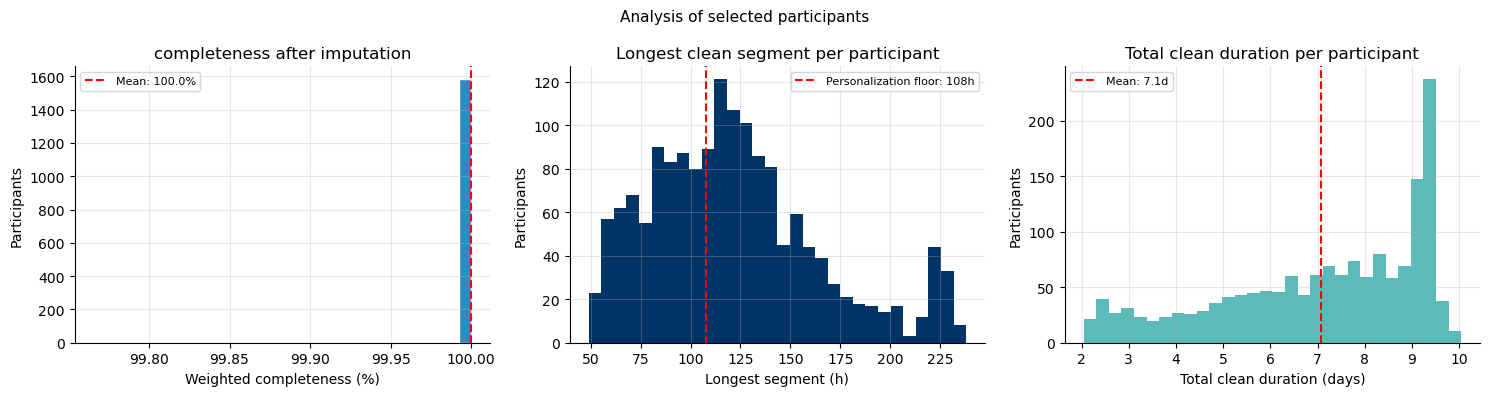

Personalization eligible (longest segment ≥108h): 958/1591


In [52]:
has_cols = all(c in cohort_df.columns for c in ["post_weighted_completeness", "longest_seg_h", "total_clean_dur_h"])

if not has_cols:
    print("Diagnostic columns not found in cohort.csv: check cohort_selection.py output.")
else:
    PERSONALIZATION_H = MIN_DURATION_H

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].hist(cohort_df["post_weighted_completeness"] * 100, bins=30,
                 color="#2E8BC0", edgecolor="white")
    axes[0].axvline(cohort_df["post_weighted_completeness"].mean() * 100,
                    color="red", linestyle="--",
                    label=f"Mean: {cohort_df['post_weighted_completeness'].mean()*100:.1f}%")
    axes[0].set_xlabel("Weighted completeness (%)")
    axes[0].set_ylabel("Participants")
    axes[0].set_title("completeness after imputation")
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
    axes[0].spines[["top", "right"]].set_visible(False)

    axes[1].hist(cohort_df["longest_seg_h"], bins=30, color="#003366", edgecolor="none")
    axes[1].axvline(PERSONALIZATION_H, color="red", linestyle="--",label=f"Personalization floor: {PERSONALIZATION_H:.0f}h")
    axes[1].set_xlabel("Longest segment (h)")
    axes[1].set_ylabel("Participants")
    axes[1].set_title("Longest clean segment per participant")
    axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
    axes[1].spines[["top", "right"]].set_visible(False)

    axes[2].hist(cohort_df["total_clean_dur_h"] / 24, bins=30, color="#5BBABA", edgecolor="none")
    axes[2].axvline(cohort_df["total_clean_dur_h"].mean() / 24, color="red", linestyle="--",
                    label=f"Mean: {cohort_df['total_clean_dur_h'].mean()/24:.1f}d")
    axes[2].set_xlabel("Total clean duration (days)")
    axes[2].set_ylabel("Participants")
    axes[2].set_title("Total clean duration per participant")
    axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)
    axes[2].spines[["top", "right"]].set_visible(False)

    plt.suptitle("Analysis of selected participants", fontsize=11)
    plt.tight_layout()
    plt.show()

    n_pers = cohort_df["personalization_eligible"].sum() if "personalization_eligible" in cohort_df.columns else "N/A"
    print(f"Personalization eligible (longest segment ≥{PERSONALIZATION_H:.0f}h): "
          f"{n_pers}/{len(cohort_df)}")

## Stage 3.1: Glycemic state representation

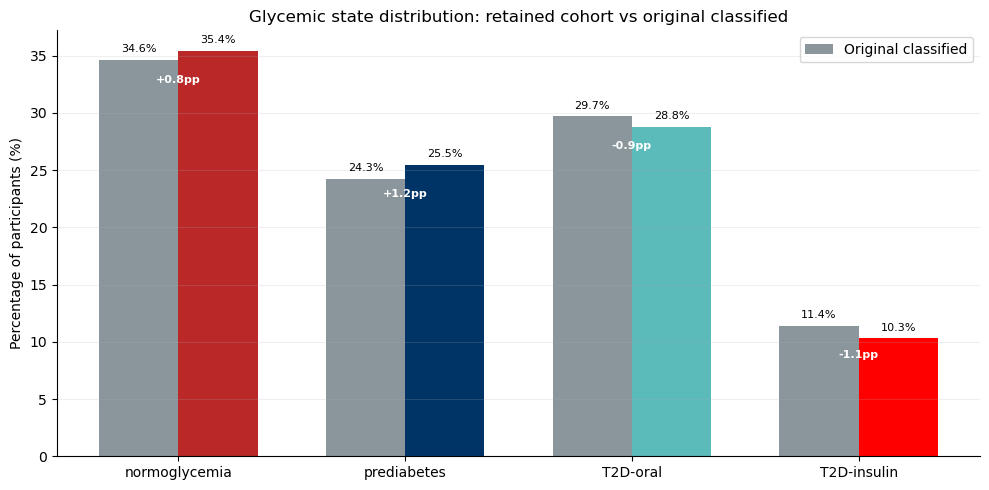

      stratum  orig_n  ret_n  retention_pct  orig_pct   ret_pct  shift_pp  non_trivial
normoglycemia     655    564      86.106870 34.619450 35.449403  0.829953        False
  prediabetes     459    405      88.235294 24.260042 25.455688  1.195646        False
     T2D-oral     562    458      81.494662 29.704017 28.786926 -0.917090        False
  T2D-insulin     216    164      75.925926 11.416490 10.307982 -1.108508        False


In [53]:
if stratum_rep.empty or "orig_pct" not in stratum_rep.columns:
    print("stage3_stratum_representation.csv not found or incomplete.")
else:
    strata   = stratum_rep["stratum"].tolist()
    orig_pct = stratum_rep["orig_pct"].tolist()
    ret_pct  = stratum_rep["ret_pct"].tolist()
    shift_pp = stratum_rep["shift_pp"].tolist()

    x     = np.arange(len(strata))
    width = 0.35
    colors = ["#BA2828", "#003366", "#5BBABA", "#FF0000"]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars_orig = ax.bar(x - width/2, orig_pct, width, label="Original classified", color="#828F96EF")
    bars_ret  = ax.bar(x + width/2, ret_pct,  width,     color=colors[:len(strata)])

    for i, (op, rp, sp) in enumerate(zip(orig_pct, ret_pct, shift_pp)):
        ax.text(x[i] - width/2, op + 0.5, f"{op:.1f}%", ha="center", va="bottom", fontsize=8)
        ax.text(x[i] + width/2, rp + 0.5, f"{rp:.1f}%", ha="center", va="bottom", fontsize=8)
        color = "red" if abs(sp) > STRATUM_TOL_PP else "white"
        ax.text(x[i], max(op, rp) - 3, f"{sp:+.1f}pp", ha="center", va="bottom", fontsize=8, color=color, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(strata)
    ax.set_ylabel("Percentage of participants (%)")
    ax.set_title("Glycemic state distribution: retained cohort vs original classified")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.2, axis="y")
    plt.tight_layout()
    plt.show()

    # Summary table
    print(stratum_rep[["stratum", "orig_n", "ret_n", "retention_pct",
                        "orig_pct", "ret_pct", "shift_pp", "non_trivial"]].to_string(index=False))

## Stage 3.2: Distribution drift tests

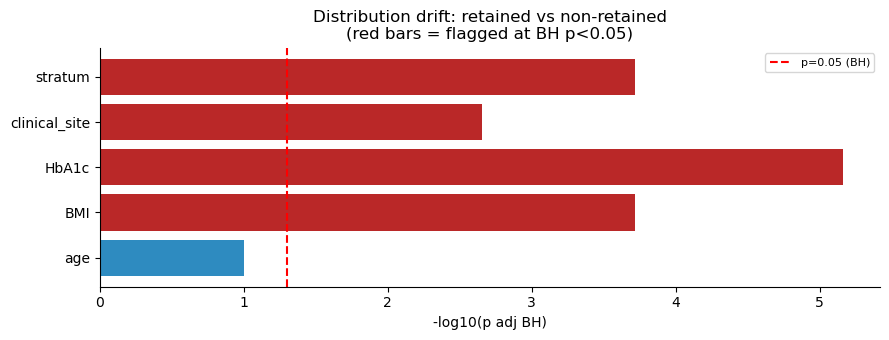

     variable  test      stat  p_value  p_adj_BH  flagged
          age KS+MW  0.058813 0.100297  0.100297    False
          BMI KS+MW  0.126398 0.000115  0.000191     True
        HbA1c KS+MW  0.146140 0.000001  0.000007     True
clinical_site  chi2 12.671054 0.001772  0.002215     True
      stratum  chi2 21.478356 0.000084  0.000191     True

4/5 variables flagged (BH p<0.05).


In [54]:
if dist_test_df.empty:
    print("stage3_distribution_tests.csv not found or Stage 3.2 was skipped.")
else:
    fig, ax = plt.subplots(figsize=(9, max(3, len(dist_test_df) * 0.5 + 1)))

    colors = ["#BA2828" if r else "#2E8BC0" for r in dist_test_df["flagged"]]
    bars = ax.barh(dist_test_df["variable"], -np.log10(dist_test_df["p_adj_BH"].clip(lower=1e-10)), color=colors)
    ax.axvline(-np.log10(0.05), color="red", linestyle="--", label="p=0.05 (BH)")
    ax.set_xlabel("-log10(p adj BH)")
    ax.set_title("Distribution drift: retained vs non-retained\n" "(red bars = flagged at BH p<0.05)")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

    print(dist_test_df[["variable", "test", "stat", "p_value", "p_adj_BH", "flagged"]].to_string(index=False))
    n_flagged = int(dist_test_df["flagged"].sum())
    print(f"\n{n_flagged}/{len(dist_test_df)} variables flagged (BH p<0.05).")

## Stage 3.3: Benchmark metrics

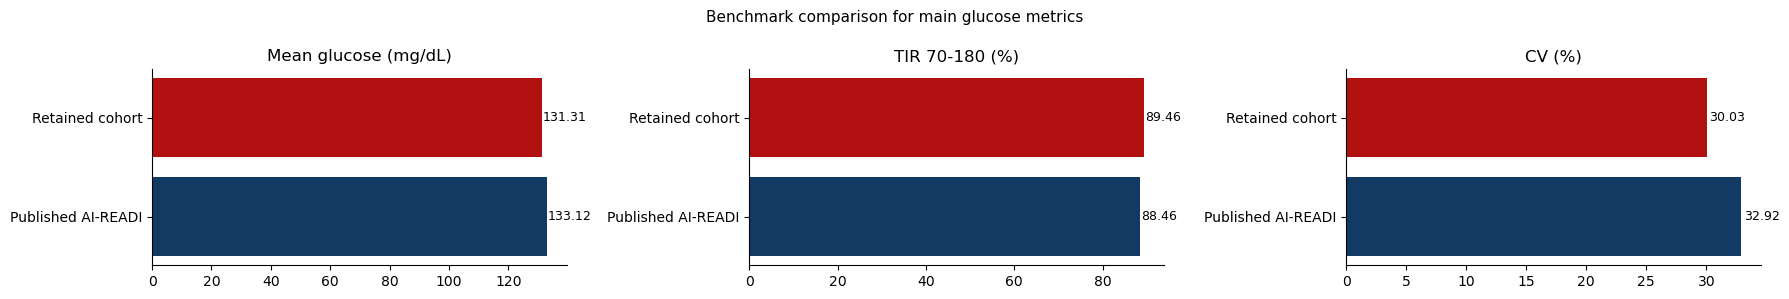

In [57]:
bench = meta_json.get("benchmark", {})
if not bench:
    print("No benchmark data in metadata JSON.")
else:
    metrics  = list(bench.keys())
    coh_vals = [bench[m]["cohort"]    for m in metrics]
    ref_vals = [bench[m]["reference"] for m in metrics]
    has_ref  = any(v is not None and not (isinstance(v, float) and np.isnan(v)) for v in ref_vals)

    fig, axes = plt.subplots(1, len(metrics), figsize=(6 * len(metrics), 3))
    if len(metrics) == 1:
        axes = [axes]

    for i, (metric, coh, ref) in enumerate(zip(metrics, coh_vals, ref_vals)):
        ax = axes[i]
        labels  = ["Retained cohort"]
        values  = [coh]
        bar_col = ["#B10E0EFC"]
        if has_ref and ref is not None and not (isinstance(ref, float) and np.isnan(ref)):
            labels  = ["Published AI-READI"] + labels
            values  = [ref] + values
            bar_col = ["#123A63"] + bar_col
        ax.barh(labels, values, color=bar_col)
        for j, v in enumerate(values):
            ax.text(v + 0.2, j, f"{v:.2f}", va="center", fontsize=9)
        ax.set_title(metric)
        ax.spines[["top", "right"]].set_visible(False)

    plt.suptitle("Benchmark comparison for main glucose metrics", fontsize=11)
    plt.tight_layout()
    plt.show()

##  summary of all files 

In [ ]:
print(f"Artifact tag    : {meta_json.get('artifact_tag', 'N/A')}")
print(f"Input parquet   : {meta_json.get('input_parquet', 'N/A')}")
print()
counts = meta_json.get("counts", {})
for k, v in counts.items():
    print(f"  {k:<35}: {v:,}")
print()
print(f"cohort.csv           : {len(cohort_df)} rows")
print(f"segments.csv         : {len(segments_df)} rows")
print(f"forecast_windows.csv : {len(windows_df):,} rows")

Artifact tag    : 20260515T202247Z_unknown
Input parquet   : /home/myriamcharfeddine/CGM/Data/enriched_multimodal/final_multimodal_dataset_20260515_184339.parquet

  raw                                : 1,892
  after_duration_floor               : 1,730
  after_trim                         : 1,703
  after_segmentation                 : 1,591
  total_segments                     : 2,619
  total_forecast_windows             : 142,823

cohort.csv           : 1591 rows
segments.csv         : 2619 rows
forecast_windows.csv : 142,823 rows
